# **GUIDE**: CODEC MODULE

This notebook is designed to provide an introduction to the codec module of this simulation pipeline. This module generates spectra based on simulation data passed from the rendering module. By the end of this notebook, you'll be able to import your own simulation data, create the corresponding spectra plots, and understand its components!

### **Setup**

#### **Part 1: Codec Module**

This section walks you through the import and setup process for the codec module.

**Steps**:

1. Identify and copy the path to the directory where `codec.py` is located on your machine.
2. Paste the path in the cell below (`codec_path`).
3. Run the cell to import the `CodecRunner` class.

In [1]:
import sys
import os

codec_path = '../spec_module'

# Add the path to where main.py is located
sys.path.insert(0, os.path.abspath(codec_path))

from codec import CodecRunner  # Import just the renderer function

#### **Part 2: Accessing Simulation Data**

This module accesses simulation data to create the corresponding spectra.

**For this guide, we will be using the `default_sim` data from the simulation we ran in the `rendering` module guide.**

***Note**: If you have not yet run the `default_sim`, please work through the `rendering` notebook first to get an understanding of the `rendering` module.*

All simulation data is stored in the directory created when the simulation is run. To create the spectra, we will need to identify the following information from the simulation directory:

1. Name of file with `default_sim` simulation data (or any other simulation you choose)
    - *All file names are formatted as `'{simulation_name}.h5'` (ex. `default_sim.h5`)*

2. Path to the directory containing the `default_sim` simulation data (or any other simulation you choose)
    - *`default_sim.h5` is stored in the folder called `default_sim` (created when the simulation was run)*

### **Initialize CodecRunner()**

First, we want to initialize a `CodecRunner()` object. This class stores all methods relevant to the user and serves as a central "runner" for all back-end processing functions.

To initialize the object, we need to find the following information and fill in the cell below. Then, run the cell to initialize the class object.

**Find these**:

1. Name of file with `default_sim` simulation data (or any other simulation you choose)
2. Path to the directory containing the `default_sim` simulation data (or any other simulation you choose)
3. Path to the directory where the *picaso reference data* is located on your machine

In [2]:
h5_file = 'default_sim.h5'  # NAME OF FILE WITH DEFAULT_SIM SIMULATION DATA
h5_dir = 'C:/Aakanksha/UArizona/SO-Polar Vortex/polarVortexJwst/notebooks/output/default_sim'  # DIRECTORY WITH DEFAULT_SIM SIMULATION DATA
spec_path = 'C:/Aakanksha/UArizona/SO-Polar Vortex/polarVortexJwst/spec_module'  # DIRECTORY WITH PICASO REFERENCE DATA

codec_runner = CodecRunner(h5_file, h5_dir, spec_path)

### **Codec Configuration**

#### **Spec Configuration**

To configure the codec, we need to find the spec folder and the name of the chosen spec configuration.

The `spec_config` variable below stores the name of the specific, chosen spectral configuration.

Here's the breakdown on how these configurations are named:

* `1200k` refers to the temperature in Kelvin of the reference spectrum
* `clouds=20` refers to the cloud thickness of the reference spectrum

#### **Select Inclinations**

Once the configurations are selected, we can specify the inclinations at which we want to view the spectra.

The inclinations are listed in the following format:

`inclinations = ['0', '15', '30']`


The chosen inclinations must match the inclinations of the chosen simulation; the spectra cannot be created without existing simulation data. For example, `default_sim` was run with the inclinations `0` and `30` degrees. Only these specific inclination angles will have spectra created. 

Run the cell below to set up the codec configuration!

In [3]:
spec_config = f'1200k_clouds=20'
spec_folder = 'bd_grid_noCH4_20251209_153457'

inclinations = ['0', '15', '30']

### **Create the Spectra**

Now that all necessary configurations have been established, we can run the `run_codec()` method to create the spectra!


===== CODEC PROCESSING =====
Running photometry configuration: timeseries_default_sim_1200k_clouds=20

### STEP 1: Initialize Codec System ###

Found 20 model IDs in the summary:
['bd_1200_10000_1.0E+07_1.00_cloudy', 'bd_1200_10000_1.0E+07_1.01_cloudy', 'bd_1200_10000_1.0E+07_1.02_cloudy', 'bd_1200_10000_1.0E+07_1.03_cloudy', 'bd_1200_10000_1.0E+07_1.04_cloudy', 'bd_1200_10000_1.0E+07_1.05_cloudy', 'bd_1200_10000_1.0E+07_1.06_cloudy', 'bd_1200_10000_1.0E+07_1.07_cloudy', 'bd_1200_10000_1.0E+07_1.08_cloudy', 'bd_1200_10000_1.0E+07_1.09_cloudy', 'bd_1200_10000_1.0E+07_1.10_cloudy', 'bd_1200_10000_1.0E+07_1.11_cloudy', 'bd_1200_10000_1.0E+07_1.12_cloudy', 'bd_1200_10000_1.0E+07_1.13_cloudy', 'bd_1200_10000_1.0E+07_1.14_cloudy', 'bd_1200_10000_1.0E+07_1.15_cloudy', 'bd_1200_10000_1.0E+07_1.16_cloudy', 'bd_1200_10000_1.0E+07_1.17_cloudy', 'bd_1200_10000_1.0E+07_1.18_cloudy', 'bd_1200_10000_1.0E+07_1.19_cloudy']

Sample params file: 
{'Teff': 1200, 'C_to_O': 0.0, 'mh': 1.0, 'gravity': 10000

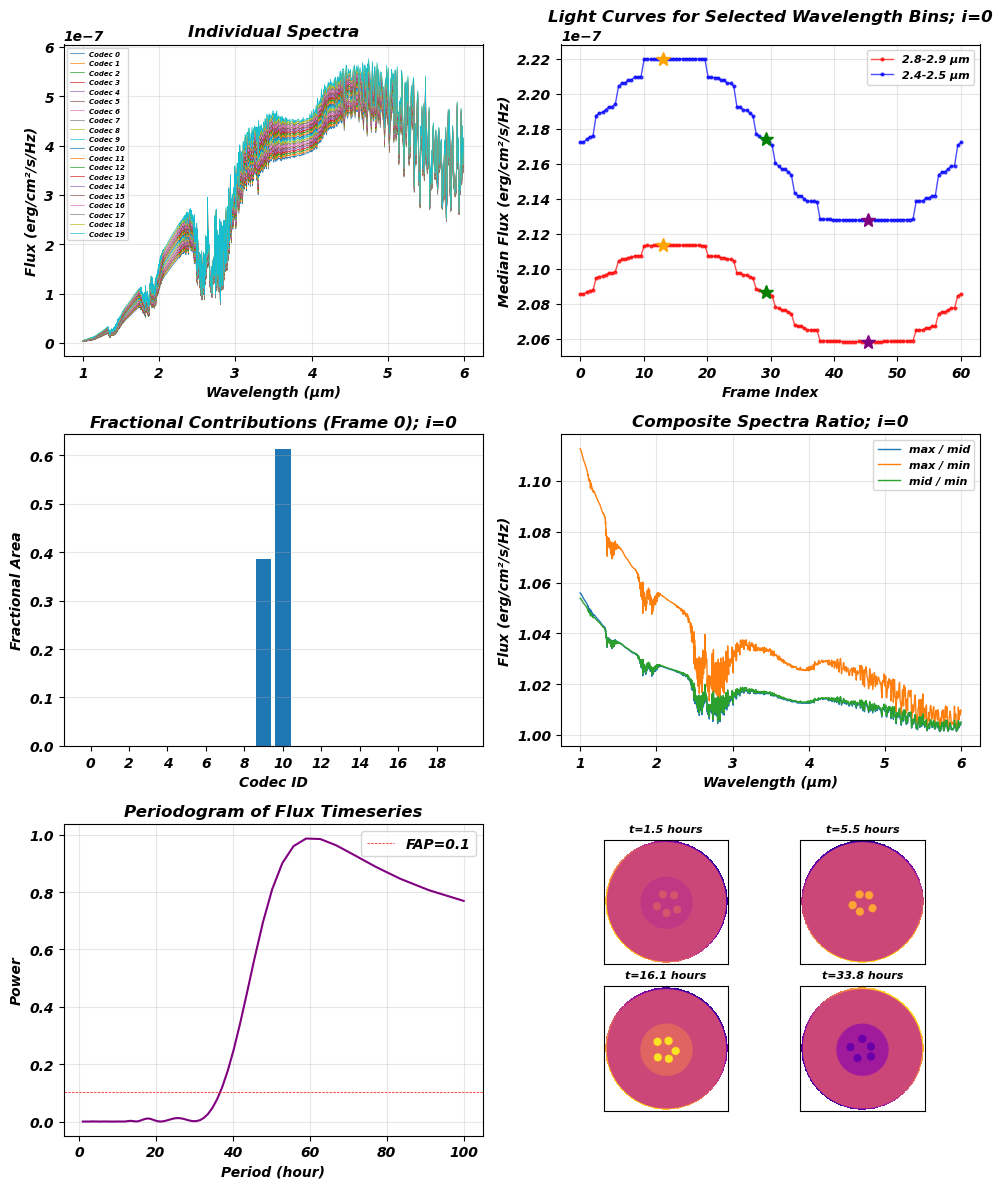


### Spectra Information ###
Loaded 20 spectra
Wavelength range: 1.000 - 5.995 μm
Number of wavelength points: 1255
Inclination: 15 - data not found

### Visualizing Spectra ###

### Processing Single Frame; i=30 ###

Saved visualization to  codecSummary_i=30.pdf


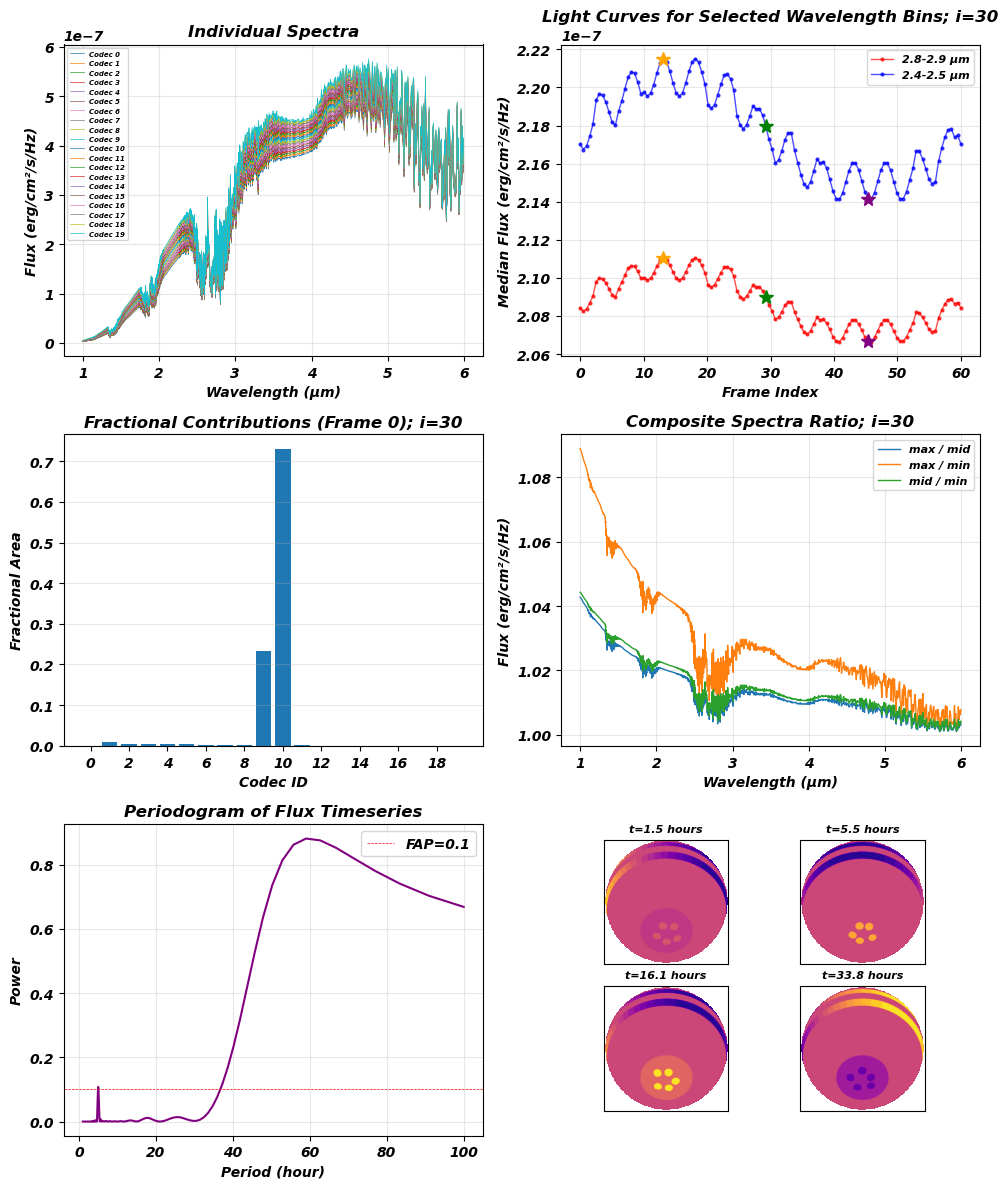


### Spectra Information ###
Loaded 20 spectra
Wavelength range: 1.000 - 5.995 μm
Number of wavelength points: 1255


In [4]:
codec_runner.run_codec(spec_config, spec_folder, inclinations=inclinations)

### **Understanding the Output**

Each output image contains 6 panels, each containing important information regarding the spectrum at the specific inclination. Let's understand what each panel represents:

#### **Panel 1: Individual Spectra**

**What it plots**: Individual spectra for each codec, where each codec corresponds to different cloud thickness values

**Noteable Features**:
* Codec 0 = most cloudy
* Codec 19 = least cloudy

#### **Panel 2: Light Curves for Selected Wavelength Bins at Given Inclination**

**What it plots**: Light curves from two example wavelength bins to show different sinusoidal patterns

**Noteable Features**:
* Colored stars indicate important points in light curve
    * Yellow star = maximum flux
    * Green star = medium flux
    * Purple star = minimum flux
* Short periods corresponding to brown dwarf rotation
* Long periods corresponding to polar cap brightness variation
* Shape and visible periodicity of lightcurves changes based on the inclination angle

#### **Panel 3: Fractional Contributions at Frame 0 for Given Inclination**

**What it plots**: Fraction of the total area contributed by each Codec ID at frame 0 for the given inclination

**Noteable Features**:
* Varies according to the inclination angle as other features become visible

#### **Panel 4: Composite Spectral Ratio at Given Inclination**

**What it plots**: Ratios between maximum, minimum, and middle spectra at the given inclination

**Noteable Features**:

#### **Panel 5: Periodogram of Flux Timeseries**

**What it plots**: Periodogram of the flux timeseries to show the power of a period in the data

**Noteable Features**:
* `False Alarm Probability (FAP)`: Power threshold above which the period is considered significant
* High periodicity at 0 inclination due to polar cap variation being dominant
* Shape varies strongly with inclination as new features become visible

#### **Panel 6: Images of Brown Dwarf at Specific Frames**

**What it plots**: Images of the brown dwarf at 1.5, 5.5 16.1, and 33.8 hours

**Noteable Features**:
* Polar cap, vortices, and bands are visible at all times